In [2]:
pip install torchtext

   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ---------------------------------------- 1.1/1.1 MB 15.3 MB/s eta 0:00:00

   ---------------------------------------- 2/2 [torchtext]

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip list

Package                  Version
------------------------ ------------
absl-py                  2.3.1
anaconda-anon-usage      0.7.1
annotated-types          0.6.0
archspec                 0.2.3
asttokens                3.0.0
astunparse               1.6.3
beautifulsoup4           4.13.4
boltons                  25.0.0
brotlicffi               1.0.9.2
certifi                  2025.7.14
cffi                     1.17.1
charset-normalizer       3.3.2
colorama                 0.4.6
comm                     0.2.3
conda                    25.5.1
conda-anaconda-telemetry 0.2.0
conda-anaconda-tos       0.2.1
conda-content-trust      0.2.0
conda-libmamba-solver    25.4.0
conda-package-handling   2.4.0
conda_package_streaming  0.12.0
contourpy                1.3.3
cryptography             45.0.3
cycler                   0.12.1
debugpy                  1.8.15
decorator                5.2.1
distro                   1.9.0
executing                2.2.0
filelock                 3.13.1
flatbuffers   

In [7]:
import torch
torch.cuda.is_available()
device = 'cuda'

In [11]:
w = torch.tensor(1.0, requires_grad=True)
x = 3

In [14]:
a = w*x
out = a ** 2
out # 역전파가 가능하도록 grad_fn이 생성된 것을 확인할 수 있음

tensor(9., grad_fn=<PowBackward0>)

In [16]:
print(w.grad)

None


In [19]:
x = 3
w = torch.tensor(1.0, requires_grad=True)
z = w*x
out = z ** 2
out.backward()
print('out을 w로 미분한 값', w.grad)

out을 w로 미분한 값 tensor(18.)


# tensor

In [23]:
import numpy as np
data = np.array([[1,2,3],[4,5,6],[7,8,9]])
x = torch.tensor([[1,2,3],[4,5,6],[7,8,9]]) # 앞으로는 가급적 텐서 형태로 바꿔서 쓰자
print(data, x)

[[1 2 3]
 [4 5 6]
 [7 8 9]] tensor([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]])


In [24]:
x.shape

torch.Size([3, 3])

In [25]:
x.size()

torch.Size([3, 3])

In [26]:
x.ndim

2

In [27]:
x.ndimension()

2

In [28]:
x

tensor([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]])

In [32]:
x = torch.tensor([[1,2,3],[4,5,6],[7,8,9]])
x=torch.unsqueeze(x, 0) # 차원 확장
x, x.shape

(tensor([[[1, 2, 3],
          [4, 5, 6],
          [7, 8, 9]]]),
 torch.Size([1, 3, 3]))

In [33]:
x=torch.squeeze(x) # 차원 축소
x, x.shape

(tensor([[1, 2, 3],
         [4, 5, 6],
         [7, 8, 9]]),
 torch.Size([3, 3]))

In [35]:
x.view(9)

tensor([1, 2, 3, 4, 5, 6, 7, 8, 9])

In [37]:
x+1 # 브로드캐스팅 연산

tensor([[ 2,  3,  4],
        [ 5,  6,  7],
        [ 8,  9, 10]])

In [38]:
np.array([1,2,3]).shape # 고정된 축

(3,)

In [44]:
w = torch.randn(5,3, dtype=torch.float) # (고차원, 저차원) 타입은 항상 지정하는 것을 권장함
w
# 메트릭스로 표현하는데 연립방정식으로 표현하기 쉽기 때문임
x = torch.tensor([[1.,2.],[3.,4.],[5.,6.]])
w.shape, x.shape

(torch.Size([5, 3]), torch.Size([3, 2]))

In [ ]:
# wx => (5,3) (3,)
# xw => (,5) (5,3) 
w.shape

torch.Size([5, 3])

In [45]:
b = torch.randn(5,2, dtype=torch.float)
b.shape

torch.Size([5, 2])

In [48]:
w@x # torch.mm(w, x)

tensor([[-1.1839, -0.7554],
        [ 8.3648, 10.2328],
        [ 8.7380, 11.5817],
        [ 1.7955,  2.7585],
        [-0.9579, -2.8464]])

In [49]:
torch.mm(w,x).shape

torch.Size([5, 2])

In [50]:
wx = torch.mm(w,x)
z = wx + b
z

tensor([[-0.8232,  0.9679],
        [10.0458,  9.0848],
        [ 9.0261, 10.5289],
        [ 2.0334,  4.4117],
        [-0.2175, -3.6858]])

In [52]:
import numpy as np
import torch
from sklearn.datasets import make_blobs
n_dim = 2
tr_x, tr_y = make_blobs(n_samples=80, n_features=2, centers=[[1,1], [-1,-1], [1,-1], [-1,1]], shuffle=True, cluster_std=.3)
tt_x, tt_y = make_blobs(n_samples=20, n_features=2, centers=[[1,1], [-1,-1], [1,-1], [-1,1]], shuffle=True, cluster_std=.3)

In [53]:
# 임시 데이터 준비 과정
ck_y = tr_y.copy()
def label_map(y, from_, n):
    ck_y = y.copy()
    for i in from_:
        ck_y[y==i] = n
    return ck_y
tr_y=label_map(tr_y, [0,1], 0)
tr_y=label_map(tr_y, [2,3], 1)
tt_y=label_map(tt_y, [0,1], 0)
tt_y=label_map(tt_y, [2,3], 1)

In [54]:
tr_x.shape, tr_y.shape # 벡터임

((80, 2), (80,))

In [55]:
np.unique(tr_y) # 클래스가 2개인데 shape는 하나로 나오니 이진 분류를 하게됨

array([0, 1])

In [56]:
import matplotlib.pyplot as plt
def v_data(x, y=None, c ='r'):
    if y is None:
        y = [None] * len(x) # [None for _ in range(len(x))]
    for ck_x, ck_y in zip(x,y): # 메트릭스 구조로 만들 때 많이 쓴다고 하심
        if ck_y is None:
            plt.plot(ck_x[0], ck_x[1], '*', markerfacecolor='none', markeredgecolor=c)
        else:
            plt.plot(ck_x[0], ck_x[1], 'o'+c if ck_y==0 else '+'+c)
    plt.show()

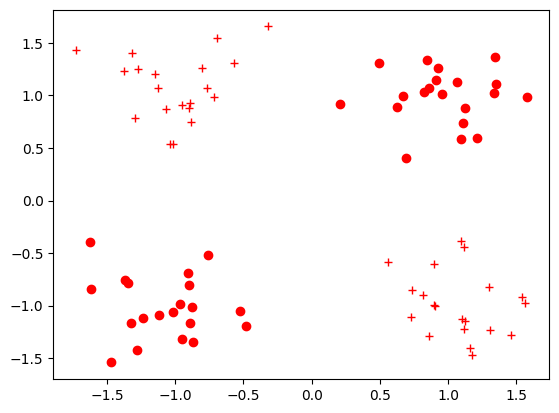

In [57]:
v_data(tr_x, tr_y) # XOR의 시각화가 됨

In [58]:
tr_x

array([[ 0.7355203 , -0.85111523],
       [-0.7171664 ,  0.98266642],
       [-1.29456693,  0.79040554],
       [ 1.54376281, -0.91454591],
       [-0.90621753, -0.69223076],
       [ 1.2977525 , -0.82511293],
       [-1.11691541, -1.09121667],
       [ 0.66995312,  0.99856418],
       [-1.61639217, -0.83883165],
       [-0.47988184, -1.19522552],
       [-0.89021135,  0.92961878],
       [ 1.06737759,  1.12649644],
       [-0.8813905 , -1.01120736],
       [ 1.09269244,  0.582225  ],
       [-1.23782632, -1.12050383],
       [ 1.3360143 ,  1.02255424],
       [ 1.35118671,  1.10741449],
       [ 1.4646016 , -1.28188623],
       [-1.32652502, -1.16828378],
       [-0.90286608,  0.87628763],
       [ 1.1642364 , -1.40570078],
       [-1.34536936, -0.78132444],
       [-0.5279736 , -1.05126805],
       [ 1.12199668, -1.14653336],
       [ 1.11773901, -0.43937593],
       [ 1.1027428 , -1.13149363],
       [ 1.17497831, -1.46792751],
       [ 0.21016068,  0.91614597],
       [ 0.81428642,

In [59]:
t_tr_x = torch.FloatTensor(tr_x)
t_tt_x = torch.FloatTensor(tt_x)
t_tr_y = torch.FloatTensor(tr_y)
t_tt_y = torch.FloatTensor(tt_y)

t_tr_x.shape, t_tr_y.shape

(torch.Size([80, 2]), torch.Size([80]))

In [60]:
class NeuralNet(torch.nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.l1 = torch.nn.Linear(self.input_size, self.hidden_size)
        self.relu = torch.nn.ReLU()
        self.l2 = torch.nn.Linear(self.hidden_size, 1) # 여기서는 어차피 출력이 한개이므로..
        self.sigmoid = torch.nn.Sigmoid()

    def forward(self, input_tensor):
        l1 = self.l1(input_tensor)
        relu = self.relu(l1)
        l2 = self.l2(relu)
        output = self.sigmoid(l2)
        return output

In [61]:
m = NeuralNet(2,5)
criterion = torch.nn.BCELoss()
opt = torch.optim.SGD(m.parameters(), lr=3e-2)
epochs = 1000

In [62]:
py = m(t_tt_x)
ty = t_tt_y
# ty.shape, py.squeeze().shape
test_loss = criterion(py.squeeze(), ty) # 앞이 예측(py)여야 함
test_loss

tensor(0.7367, grad_fn=<BinaryCrossEntropyBackward0>)

In [63]:
test_loss.item()

0.7366769909858704

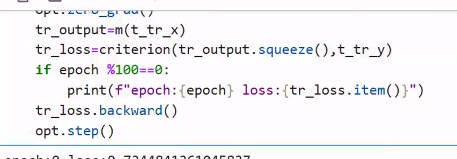

In [64]:
for epoch in range(epochs):
    m.train()
    opt.zero_grad()
    tr_output = m(t_tr_x)
    tr_loss = criterion(tr_output.squeeze(), t_tr_y)
    if epoch % 100 == 0:
        print(f'epoch:{epoch}\t loss: {tr_loss.item()}')
    tr_loss.backward()
    opt.step()

epoch:0	 loss: 0.7208877205848694
epoch:100	 loss: 0.6461982727050781
epoch:200	 loss: 0.5777508020401001
epoch:300	 loss: 0.49029093980789185
epoch:400	 loss: 0.4014335572719574
epoch:500	 loss: 0.32067522406578064
epoch:600	 loss: 0.25378018617630005
epoch:700	 loss: 0.20357432961463928
epoch:800	 loss: 0.16741161048412323
epoch:900	 loss: 0.14149253070354462


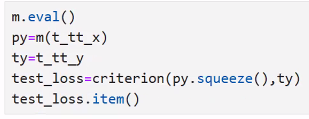

In [65]:
m.eval()
py = m(t_tt_x)
ty = t_tt_y
test_loss = criterion(py.squeeze(), ty)
test_loss.item()

0.13223376870155334

In [66]:
m

NeuralNet(
  (l1): Linear(in_features=2, out_features=5, bias=True)
  (relu): ReLU()
  (l2): Linear(in_features=5, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

In [67]:
m.state_dict()

OrderedDict([('l1.weight',
              tensor([[ 0.3872, -0.5357],
                      [-0.8846, -0.7747],
                      [ 0.9839, -1.1128],
                      [ 0.9504, -1.0806],
                      [-1.4032,  1.2812]])),
             ('l1.bias',
              tensor([-0.6795,  0.0421, -0.2581, -0.2410, -0.3371])),
             ('l2.weight',
              tensor([[ 0.1209, -0.9638,  1.3129,  1.2461,  1.8692]])),
             ('l2.bias', tensor([-1.5677]))])

In [68]:
torch.save(m.state_dict(), 'torch_model.pt')

In [69]:
n_m = NeuralNet(2,5)
print(n_m.state_dict()) # 무작위 출력됨(모델을 로드하지 않았기 때문임)

OrderedDict({'l1.weight': tensor([[ 0.0108,  0.3865],
        [ 0.6116, -0.2679],
        [-0.5845,  0.5720],
        [-0.6720, -0.0021],
        [-0.0029, -0.4826]]), 'l1.bias': tensor([ 0.5837, -0.5523,  0.3611, -0.6558, -0.3744]), 'l2.weight': tensor([[-0.1259,  0.1220, -0.0726,  0.0168, -0.2696]]), 'l2.bias': tensor([0.3350])})


In [70]:
n_m.load_state_dict(torch.load('torch_model.pt'))
print(n_m.state_dict())

OrderedDict({'l1.weight': tensor([[ 0.3872, -0.5357],
        [-0.8846, -0.7747],
        [ 0.9839, -1.1128],
        [ 0.9504, -1.0806],
        [-1.4032,  1.2812]]), 'l1.bias': tensor([-0.6795,  0.0421, -0.2581, -0.2410, -0.3371]), 'l2.weight': tensor([[ 0.1209, -0.9638,  1.3129,  1.2461,  1.8692]]), 'l2.bias': tensor([-1.5677])})


In [71]:
n_m.eval()
n_m(torch.FloatTensor([-1,1])).item()

0.9354298114776611

# 위 코드를 참조하여 AND와 OR을 만드시오

# AND 연산

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

In [3]:
def label_map(y, from_, n):
    ck_y = y.copy()
    for i in from_:
        ck_y[y==i] = n
    return ck_y
def v_data(x, y=None, c ='r'):
    if y is None:
        y = [None] * len(x)
    for ck_x, ck_y in zip(x,y): # 메트릭스 구조로 만들 때 많이 쓴다고 하심
        if ck_y is None:
            plt.plot(ck_x[0], ck_x[1], '*', markerfacecolor='none', markeredgecolor=c)
        else:
            plt.plot(ck_x[0], ck_x[1], 'o'+c if ck_y==0 else '+'+c)
    plt.show()

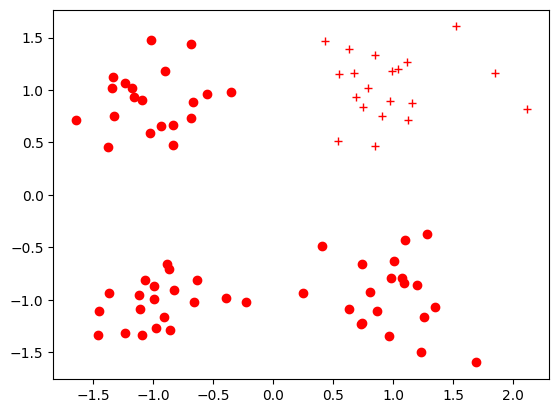

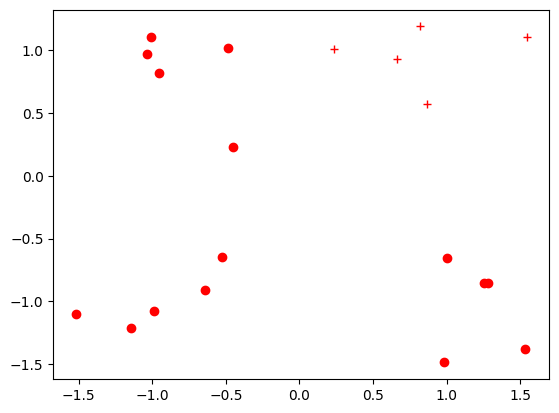

In [4]:
#AND
n_dim=2
tr_x,tr_y=make_blobs(n_samples=80,n_features=2,centers=[[-1,-1],[1,1],[1,-1],[-1,1]],shuffle=True,cluster_std=0.3)
tt_x,tt_y=make_blobs(n_samples=20,n_features=2,centers=[[-1,-1],[1,1],[1,-1],[-1,1]],shuffle=True,cluster_std=0.3)

tr_y=label_map(tr_y,[2,3],0)
#tr_y=label_map(tr_y,[0,2,3],1)
tt_y=label_map(tt_y,[2,3],0)
#tt_y=label_map(tt_y,[0,2,3],1)
v_data(tr_x,tr_y)
v_data(tt_x,tt_y)

In [5]:
t_tr_x = torch.FloatTensor(tr_x)
t_tr_y = torch.FloatTensor(tr_y)
t_tt_x = torch.FloatTensor(tt_x)
t_tt_y = torch.FloatTensor(tt_y)

t_tr_x.shape, t_tr_y.shape, t_tt_x.shape, t_tt_y.shape

(torch.Size([80, 2]), torch.Size([80]), torch.Size([20, 2]), torch.Size([20]))

In [6]:
t_tt_y

tensor([1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0., 0., 0., 0., 1.,
        0., 0.])

In [7]:
class AndGate(nn.Module):
    def __init__(self, input_data, hidden_data):
        super().__init__()
        self.input_data = input_data
        self.hidden_data = hidden_data
        self.l1 = nn.Linear(self.input_data, self.hidden_data)
        self.relu = nn.ReLU()
        self.l2 = nn.Linear(self.hidden_data, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, input_tensor):
        l1 = self.l1(input_tensor)
        relu = self.relu(l1)
        l2 = self.l2(relu)
        output = self.sigmoid(l2)
        return output

In [8]:
m = AndGate(2,5)
criterion = nn.BCELoss()
optimizer = optim.SGD(m.parameters(), lr=2e-2)
epochs = 1000

In [9]:
for epoch in range(epochs):
    m.train()
    optimizer.zero_grad()
    tr_output = m(t_tr_x)
    tr_loss = criterion(tr_output.squeeze(), t_tr_y)
    if epoch % 99 == 0:
        print(f'epochs: {epoch}\t loss: {tr_loss.item()}')
    tr_loss.backward()
    optimizer.step()

epochs: 0	 loss: 0.6007078289985657
epochs: 99	 loss: 0.4124157428741455
epochs: 198	 loss: 0.30340903997421265
epochs: 297	 loss: 0.233011394739151
epochs: 396	 loss: 0.18912717700004578
epochs: 495	 loss: 0.1600203812122345
epochs: 594	 loss: 0.13898561894893646
epochs: 693	 loss: 0.12289352715015411
epochs: 792	 loss: 0.10988358408212662
epochs: 891	 loss: 0.09912259876728058
epochs: 990	 loss: 0.09051559865474701


In [10]:
m.eval()
py = m(t_tt_x)
ty = t_tt_y
criterion(py.squeeze(), ty).item()

0.09760884195566177

In [ ]:
print(m(torch.FloatTensor([1,1])).item()) 
print(m(torch.FloatTensor([1,-1])).item())
print(m(torch.FloatTensor([-1,1])).item())
print(m(torch.FloatTensor([-1,-1])).item())

0.9458165764808655
0.01558683067560196
0.17277587950229645
0.00536553468555212


# OR 연산

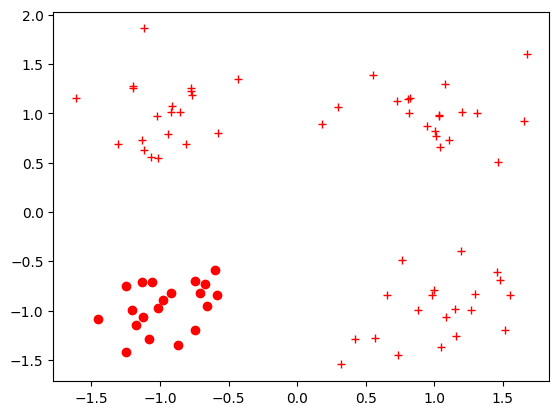

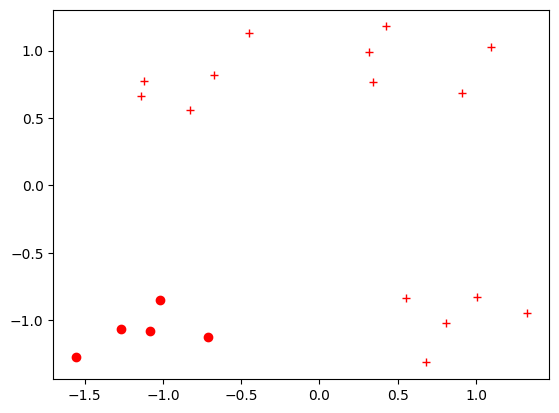

In [37]:
n_dim=2
tr_x,tr_y=make_blobs(n_samples=80,n_features=2,centers=[[-1,-1],[1,1],[1,-1],[-1,1]],shuffle=True,cluster_std=0.3)
tt_x,tt_y=make_blobs(n_samples=20,n_features=2,centers=[[-1,-1],[1,1],[1,-1],[-1,1]],shuffle=True,cluster_std=0.3)

tr_y=label_map(tr_y,[1,2,3],1)
#tr_y=label_map(tr_y,[0,2,3],1)
tt_y=label_map(tt_y,[1,2,3],1)
#tt_y=label_map(tt_y,[0,2,3],1)

# OR
v_data(tr_x, tr_y)
v_data(tt_x, tt_y)

In [38]:
t_tr_x = torch.FloatTensor(tr_x)
t_tr_y = torch.FloatTensor(tr_y)
t_tt_x = torch.FloatTensor(tt_x)
t_tt_y = torch.FloatTensor(tt_y)

t_tr_x.shape, t_tr_y.shape, t_tt_x.shape, t_tt_y.shape

(torch.Size([80, 2]), torch.Size([80]), torch.Size([20, 2]), torch.Size([20]))

In [39]:
t_tt_y

tensor([1., 1., 1., 1., 0., 0., 1., 1., 1., 0., 1., 0., 1., 0., 1., 1., 1., 1.,
        1., 1.])

In [40]:
class ORGate(nn.Module):
    def __init__(self, input_data, hidden_data):
        super().__init__()
        self.input_data = input_data
        self.hidden_data = hidden_data
        self.l1 = nn.Linear(self.input_data, self.hidden_data)
        self.relu = nn.ReLU()
        self.l2 = nn.Linear(self.hidden_data, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, input_tensor):
        l1 = self.l1(input_tensor)
        relu = self.relu(l1)
        l2 = self.l2(relu)
        output = self.sigmoid(l2)
        return output

In [41]:
or_gate = ORGate(2,5)
criterion = nn.BCELoss()
optimizer = optim.SGD(or_gate.parameters(), lr=2e-2)
epochs = 1000

In [42]:
for epoch in range(epochs):
    or_gate.train()
    optimizer.zero_grad()
    tr_output = or_gate(t_tr_x)
    tr_loss = criterion(tr_output.squeeze(), t_tr_y)
    if epoch % 99 == 0:
        print(f'epochs: {epoch}\t loss: {tr_loss.item()}')
    tr_loss.backward()
    optimizer.step()

epochs: 0	 loss: 0.7625567317008972
epochs: 99	 loss: 0.5440079569816589
epochs: 198	 loss: 0.443650484085083
epochs: 297	 loss: 0.37326332926750183
epochs: 396	 loss: 0.3091650903224945
epochs: 495	 loss: 0.2491142749786377
epochs: 594	 loss: 0.198766827583313
epochs: 693	 loss: 0.15814213454723358
epochs: 792	 loss: 0.1257018744945526
epochs: 891	 loss: 0.10063115507364273
epochs: 990	 loss: 0.08173752576112747


In [43]:
or_gate.eval()
print(or_gate(torch.FloatTensor([-1,-1])))
print(or_gate(torch.FloatTensor([-1,1])))
print(or_gate(torch.FloatTensor([1,-1])))
print(or_gate(torch.FloatTensor([1,1])))

tensor([0.0856], grad_fn=<SigmoidBackward0>)
tensor([0.9753], grad_fn=<SigmoidBackward0>)
tensor([0.8761], grad_fn=<SigmoidBackward0>)
tensor([0.9953], grad_fn=<SigmoidBackward0>)
